# 🔋 MGA Exploration Notebook
### Interactive Near-Optimal Solution Exploration for PyPSA Networks

This notebook allows you to interactively explore the **near-optimal feasible space** of your PyPSA energy system model.  
Instead of a single cost-optimal solution, you can navigate between alternative solutions that are only slightly more expensive but may differ significantly in structure — differing in renewable capacity mix, emissions, or transmission usage.

**Workflow overview:**

| Step | Description |
|------|-------------|
| 1 | Load your PyPSA network (`.nc` file) |
| 2 | Define Properties of Interest (PoIs) |
| 3 | Run the Preparation Phase (once per network) |
| 4 | Navigate interactively to alternative solutions |
| 5 | Traverse the path between solutions |

> ⚠️ The preparation phase is computationally intensive and may take several minutes. It only needs to be run **once** — results are saved and reloaded automatically.


---
## Section 1 — Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, HTML


### 1.1 Load Your Network

Set the path to your saved PyPSA network file (`.nc` format) below.


In [2]:
# ── USER CONFIGURATION ──────────────────────────────────────────
network_path = "my_network.nc"   # <-- change this to your file path
preparation_state_path = "preparation_state.nc"  # saved after first run
epsilon = 0.10  # near-optimality threshold (10% above optimal cost)
# ────────────────────────────────────────────────────────────────

# Load network (mocked here — replace with: network = pypsa.Network(network_path))
print(f"Loading network from: {network_path}")
print()

# ── Mock network summary ─────────────────────────────────────────
summary = {
    "Buses":        3,
    "Generators":   6,
    "Storage units":2,
    "Lines":        3,
    "Optimal cost": "€ 1,243,800 / year",
    "Epsilon (ε)":  f"{epsilon*100:.0f}%",
    "Cost budget":  "€ 1,368,180 / year",
}

print("─" * 40)
print("  Network Summary")
print("─" * 40)
for k, v in summary.items():
    print(f"  {k:<20} {v}")
print("─" * 40)
print("  ✓ Network loaded successfully.")


Loading network from: my_network.nc

────────────────────────────────────────
  Network Summary
────────────────────────────────────────
  Buses                3
  Generators           6
  Storage units        2
  Lines                3
  Optimal cost         € 1,243,800 / year
  Epsilon (ε)          10%
  Cost budget          € 1,368,180 / year
────────────────────────────────────────
  ✓ Network loaded successfully.


---
## Section 2 — Define Properties of Interest (PoIs)

**Properties of Interest (PoIs)** are the solution metrics you care about — for example, the installed capacity of solar or wind, total CO₂ emissions, or storage capacity. The exploration engine will let you navigate the near-optimal space in terms of these properties.

Each PoI is defined as a `PoiSpec` object that bundles:
- `name` — a human-readable label shown in plots and widgets
- `unit` — the display unit (e.g. GW, tCO₂)
- `evaluate(network)` — a function that computes the PoI value from a solved network
- `linopy_expr(model)` — a function that returns the equivalent Linopy expression (used during preparation)

**Adapt the example below to match your network's generator and component names.**


In [3]:
# Dummy PoiSpec for mockup — in the real notebook this comes from mga_engine
from dataclasses import dataclass, field
from typing import Callable, List, Any

@dataclass
class PoiSpec:
    name: str
    unit: str
    generator_names: List[str] = field(default_factory=list)
    evaluate: Callable = None
    linopy_expr: Callable = None

# ── Define your PoIs here ────────────────────────────────────────

pois = [
    PoiSpec(name="Solar Capacity", unit="GW", generator_names=["Solar Bus0", "Solar Bus1"]),
    PoiSpec(name="Wind Capacity",  unit="GW", generator_names=["Wind Bus0", "Wind Bus1"]),
    PoiSpec(name="Gas Capacity",   unit="GW", generator_names=["Gas Bus0"]),
]

print(f"✓ {len(pois)} PoIs defined:")
for i, p in enumerate(pois):
    print(f"  [{i+1}] {p.name}  ({p.unit})")


✓ 3 PoIs defined:
  [1] Solar Capacity  (GW)
  [2] Wind Capacity  (GW)
  [3] Gas Capacity  (GW)


---
## Section 3 — Preparation Phase

The preparation phase samples the near-optimal feasible space by:
1. Finding **vertex samples** at the extremes of the PoI space via MP(r)
2. Finding **interior samples** by progressively tightening the suboptimality bound
3. Solving **GP(pⁱ)** for each sample to get cost vectors and dual variables

This phase runs **once per network** and its results are saved to disk. On subsequent runs, results are loaded automatically — skipping the computation entirely.


In [4]:
import os

# ── Mock preparation state check ────────────────────────────────
preparation_state_path = "preparation_state.nc"

if os.path.exists(preparation_state_path):
    print(f"✓ Found existing preparation state at: {preparation_state_path}")
    print("  Loading saved results — skipping computation.")
else:
    print("No saved state found. Running preparation phase...")
    print()
    print("[1/3] Vertex sampling via MP(r)...")
    print("      → 6 vertex samples found")
    print("[2/3] Interior sampling (ε levels: 0.04 → 0.005)...")
    print("      → 50 interior samples found")
    print("[3/3] Solving GP(pⁱ) for all samples...")
    print("      → Cost vector v and dual matrix Γ computed")
    print()
    print(f"✓ Preparation complete. State saved to: {preparation_state_path}")

print()
print("─" * 45)
print("  Preparation Summary (mocked)")
print("─" * 45)
print(f"  Total samples (P_all):    56")
print(f"  PoI dimensions (m):        3")
print(f"  Cost range:      €1.24M – €1.37M")
print(f"  Dual matrix Γ:     56 × 3")
print("─" * 45)


No saved state found. Running preparation phase...

[1/3] Vertex sampling via MP(r)...
      → 6 vertex samples found
[2/3] Interior sampling (ε levels: 0.04 → 0.005)...
      → 50 interior samples found
[3/3] Solving GP(pⁱ) for all samples...
      → Cost vector v and dual matrix Γ computed

✓ Preparation complete. State saved to: preparation_state.nc

─────────────────────────────────────────────
  Preparation Summary (mocked)
─────────────────────────────────────────────
  Total samples (P_all):    56
  PoI dimensions (m):        3
  Cost range:      €1.24M – €1.37M
  Dual matrix Γ:     56 × 3
─────────────────────────────────────────────


### 3.1 Near-Optimal Space Overview

The chart below shows the **min–max range of each PoI** across all sampled near-optimal solutions. This is the space you will explore interactively in the next section.

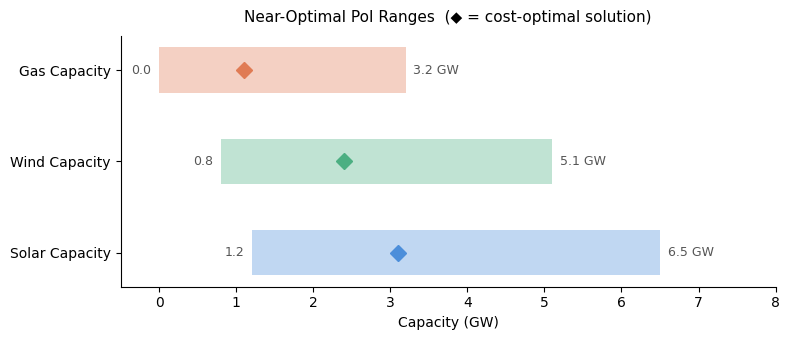

Tip: The shaded bars show the full range of feasible near-optimal values.
     The diamond ◆ marks where the cost-optimal solution sits.


In [5]:
# ── Mock PoI ranges from preparation ────────────────────────────
poi_names  = ["Solar Capacity", "Wind Capacity", "Gas Capacity"]
poi_units  = ["GW", "GW", "GW"]
poi_min    = [1.2, 0.8, 0.0]
poi_max    = [6.5, 5.1, 3.2]
poi_opt    = [3.1, 2.4, 1.1]   # optimal solution values

fig, ax = plt.subplots(figsize=(8, 3.5))

colors = ["#4C8EDA", "#4CAF82", "#E07B54"]
y_pos  = range(len(poi_names))

for i, (name, unit, lo, hi, opt, c) in enumerate(
        zip(poi_names, poi_units, poi_min, poi_max, poi_opt, colors)):
    ax.barh(i, hi - lo, left=lo, height=0.5, color=c, alpha=0.35, label=name)
    ax.barh(i, hi - lo, left=lo, height=0.5, color=c, alpha=0.0,
            edgecolor=c, linewidth=1.5)
    ax.plot(opt, i, "D", color=c, markersize=8, zorder=5)
    ax.text(hi + 0.1, i, f"{hi:.1f} {unit}", va="center", fontsize=9, color="#555")
    ax.text(lo - 0.1, i, f"{lo:.1f}", va="center", ha="right", fontsize=9, color="#555")

ax.set_yticks(list(y_pos))
ax.set_yticklabels(poi_names, fontsize=10)
ax.set_xlabel("Capacity (GW)", fontsize=10)
ax.set_title("Near-Optimal PoI Ranges  (◆ = cost-optimal solution)", fontsize=11, pad=10)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(-0.5, 8)
plt.tight_layout()
plt.savefig("poi_ranges.png", dpi=130, bbox_inches="tight")
plt.show()
print("Tip: The shaded bars show the full range of feasible near-optimal values.")
print("     The diamond ◆ marks where the cost-optimal solution sits.")


### 3.2 PoI Correlation Heatmap

The heatmap below shows how the PoIs correlate across all sampled near-optimal solutions. A strong negative correlation (dark red) means that increasing one PoI tends to decrease the other — a classic trade-off. A positive correlation (dark blue) means they move together. Use this to understand trade-offs before you start navigating.

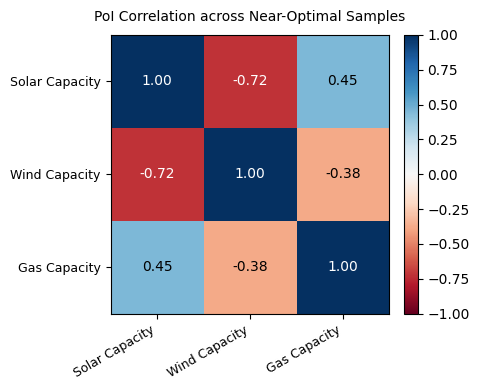

Tip: Strong negative values mean a trade-off — gaining one PoI costs another.


In [6]:
# ── Mock correlation matrix ──────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

poi_names  = ["Solar Capacity", "Wind Capacity", "Gas Capacity"]
corr = np.array([
    [ 1.00, -0.72,  0.45],
    [-0.72,  1.00, -0.38],
    [ 0.45, -0.38,  1.00],
])

fig, ax = plt.subplots(figsize=(5, 4))
cmap = plt.cm.RdBu
im   = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)

ax.set_xticks(range(len(poi_names)))
ax.set_yticks(range(len(poi_names)))
ax.set_xticklabels(poi_names, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(poi_names, fontsize=9)
ax.set_title("PoI Correlation across Near-Optimal Samples", fontsize=10, pad=10)

for i in range(len(poi_names)):
    for j in range(len(poi_names)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center",
                fontsize=10, color="white" if abs(corr[i, j]) > 0.5 else "black")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
print("Tip: Strong negative values mean a trade-off — gaining one PoI costs another.")


**How to read this heatmap:**

Each cell shows the correlation between two PoIs across all sampled near-optimal solutions:

- A value close to **-1.0** (dark red) means a strong **trade-off**: when one PoI is high, the other tends to be low. For example, Solar and Wind have a correlation of -0.72 — asking for more solar capacity while keeping wind high will be difficult.
- A value close to **+1.0** (dark blue) means the two PoIs **move together**: gaining one tends to come with gaining the other.
- A value close to **0** means the two PoIs are largely **independent** of each other in the near-optimal space.

Use this before navigating to anticipate which preferences are compatible and which will require trade-offs.


### 3.3 Cost Slack Visualization

The near-optimal space is defined by a suboptimality threshold ε. The bar below shows how much of that cost budget is currently used. The remaining slack is the room you have to explore alternative solutions.

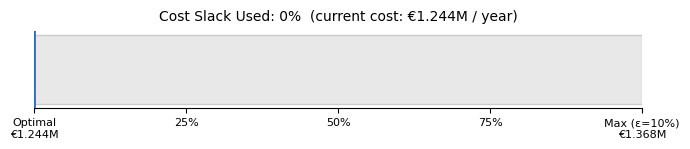

Remaining slack: 100% of the ε budget — €124,400 / year headroom.


In [7]:
# ── Mock cost slack ──────────────────────────────────────────────
optimal_cost = 1.244   # M€/year
epsilon      = 0.10
max_cost     = optimal_cost * (1 + epsilon)
current_cost = 1.244   # at start we are at the optimal solution

slack_used    = (current_cost - optimal_cost) / (max_cost - optimal_cost)
slack_used    = max(0.0, min(1.0, slack_used))

fig, ax = plt.subplots(figsize=(7, 1.6))
ax.barh(0, 1.0,        height=0.5, color="#E8E8E8", edgecolor="#ccc")
ax.barh(0, slack_used, height=0.5, color="#4C8EDA", edgecolor="none")

ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticklabels(["Optimal\n€1.244M", "25%", "50%", "75%",
                     f"Max (ε={epsilon:.0%})\n€{max_cost:.3f}M"], fontsize=8)
ax.set_title(f"Cost Slack Used: {slack_used*100:.0f}%  "
             f"(current cost: €{current_cost:.3f}M / year)", fontsize=10, pad=8)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.axvline(slack_used, color="#2C6EBA", lw=2)

plt.tight_layout()
plt.show()
print(f"Remaining slack: {(1-slack_used)*100:.0f}% of the ε budget — "
      f"€{(max_cost - current_cost)*1e6:,.0f} / year headroom.")


### 3.4 Near-Optimal Space — 2D Projection

Select two PoIs to use as axes and see all sampled near-optimal solutions projected onto that plane. The diamond marks the cost-optimal solution. Use this to get an intuitive feel for the shape of the feasible region before you start navigating.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# ── Mock sample cloud ────────────────────────────────────────────
np.random.seed(42)
n_samples = 56
poi_names = ["Solar Capacity", "Wind Capacity", "Gas Capacity"]

# Simulate correlated samples inside a rough polytope
raw = np.random.randn(n_samples, 3)
cov = np.array([[1.0, -0.7,  0.4],
                [-0.7, 1.0, -0.3],
                [0.4, -0.3,  1.0]])
L   = np.linalg.cholesky(cov)
samples = raw @ L.T
# Scale to realistic ranges
scales  = np.array([2.5, 2.0, 1.5])
offsets = np.array([3.8, 2.6, 1.1])
samples = samples * scales / 3 + offsets
samples = np.clip(samples, [1.2, 0.8, 0.0], [6.5, 5.1, 3.2])
optimal = np.array([3.1, 2.4, 1.1])

x_sel = widgets.Dropdown(options=poi_names, value="Solar Capacity",
                         description="X axis:", style={"description_width": "80px"})
y_sel = widgets.Dropdown(options=poi_names, value="Wind Capacity",
                         description="Y axis:", style={"description_width": "80px"})
out_scatter = widgets.Output()

def update_scatter(change):
    xi = poi_names.index(x_sel.value)
    yi = poi_names.index(y_sel.value)
    out_scatter.clear_output(wait=True)
    with out_scatter:
        if xi == yi:
            print("Please select two different PoIs.")
            return
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.scatter(samples[:, xi], samples[:, yi], c="#4C8EDA", alpha=0.5,
                   s=40, label="Near-optimal samples")
        ax.plot(optimal[xi], optimal[yi], "D", color="#E07B54", ms=10,
                zorder=5, label="Cost-optimal solution")
        ax.set_xlabel(f"{x_sel.value} (GW)", fontsize=10)
        ax.set_ylabel(f"{y_sel.value} (GW)", fontsize=10)
        ax.set_title("Near-Optimal Space — 2D Projection", fontsize=11, pad=10)
        ax.legend(fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        plt.show()

x_sel.observe(update_scatter, names="value")
y_sel.observe(update_scatter, names="value")
display(widgets.HBox([x_sel, y_sel]))
display(out_scatter)
update_scatter(None)


Output()

---
## Section 4 — Navigation

Set your **preferences** for the next solution using the controls below.

For each Property of Interest you specify:
- **Direction** — whether you want the value to increase (▲), decrease (▼), or stay approximately the same (=)
- **Delta (δ)** — the desired magnitude of change
- **Priority** — which PoI matters most (1 = highest priority)

The navigation algorithm will find the solution in the near-optimal space that best satisfies your preferences in priority order. If a preference is not fully achievable, it will report back what was actually possible.


In [9]:
# ── Mock current solution ────────────────────────────────────────
current_solution = {"Solar Capacity": 3.1, "Wind Capacity": 2.4, "Gas Capacity": 1.1}

# ── Navigation preference widgets ────────────────────────────────
style  = {"description_width": "140px"}
layout = widgets.Layout(width="280px")

direction_solar = widgets.ToggleButtons(options=["▲ Increase", "= Keep", "▼ Decrease"],
                   value="▲ Increase", description="Solar:", style=style)
delta_solar     = widgets.FloatSlider(value=1.5, min=0.0, max=4.0, step=0.1,
                   description="Delta (GW):", style=style, layout=layout)
priority_solar  = widgets.Dropdown(options=[1, 2, 3], value=1,
                   description="Priority:", style=style, layout=widgets.Layout(width="200px"))

direction_wind  = widgets.ToggleButtons(options=["▲ Increase", "= Keep", "▼ Decrease"],
                   value="= Keep", description="Wind:", style=style)
delta_wind      = widgets.FloatSlider(value=0.5, min=0.0, max=4.0, step=0.1,
                   description="Delta (GW):", style=style, layout=layout)
priority_wind   = widgets.Dropdown(options=[1, 2, 3], value=2,
                   description="Priority:", style=style, layout=widgets.Layout(width="200px"))

direction_gas   = widgets.ToggleButtons(options=["▲ Increase", "= Keep", "▼ Decrease"],
                   value="▼ Decrease", description="Gas:", style=style)
delta_gas       = widgets.FloatSlider(value=0.8, min=0.0, max=3.0, step=0.1,
                   description="Delta (GW):", style=style, layout=layout)
priority_gas    = widgets.Dropdown(options=[1, 2, 3], value=3,
                   description="Priority:", style=style, layout=widgets.Layout(width="200px"))

# ── Linked priority logic ─────────────────────────────────────────
_updating = [False]  # guard against recursive calls

def make_priority_observer(changed, others):
    def observer(change):
        if _updating[0]:
            return
        _updating[0] = True
        used = changed.value
        remaining = [v for v in [1, 2, 3] if v != used]
        for w, val in zip(others, remaining):
            w.value = val
        _updating[0] = False
    return observer

priority_solar.observe(make_priority_observer(priority_solar, [priority_wind, priority_gas]), names="value")
priority_wind.observe( make_priority_observer(priority_wind,  [priority_solar, priority_gas]), names="value")
priority_gas.observe(  make_priority_observer(priority_gas,   [priority_solar, priority_wind]), names="value")

# ── Layout ────────────────────────────────────────────────────────
navigate_btn = widgets.Button(description="Navigate", button_style="primary",
                layout=widgets.Layout(width="180px", height="36px"))
output_nav   = widgets.Output()

print("-" * 50)
print("  Solar Capacity")
display(widgets.HBox([direction_solar, delta_solar, priority_solar]))
print("  Wind Capacity")
display(widgets.HBox([direction_wind, delta_wind, priority_wind]))
print("  Gas Capacity")
display(widgets.HBox([direction_gas, delta_gas, priority_gas]))
print("-" * 50)
display(navigate_btn)
display(output_nav)

def on_navigate(b):
    output_nav.clear_output()
    with output_nav:
        target_solution = {"Solar Capacity": 4.6, "Wind Capacity": 2.4, "Gas Capacity": 0.3}
        messages = [
            "Solar capacity: increased by 1.5 GW  (target satisfied)",
            "Wind capacity: kept within 0.5 GW   (target satisfied)",
            "Gas capacity: decreased by 0.8 GW   (target satisfied)",
        ]

        print("Navigation Messages:")
        print("-" * 48)
        for msg in messages:
            print(" ", msg)
        print("-" * 48)

        poi_names = list(current_solution.keys())
        cur_vals  = list(current_solution.values())
        tgt_vals  = list(target_solution.values())
        x         = np.arange(len(poi_names))
        width     = 0.35

        fig, ax = plt.subplots(figsize=(7, 4))
        bars1 = ax.bar(x - width/2, cur_vals, width, label="Current solution",
                       color="#4C8EDA", alpha=0.8)
        bars2 = ax.bar(x + width/2, tgt_vals, width, label="Target solution",
                       color="#E07B54", alpha=0.8)

        ax.set_xticks(x)
        ax.set_xticklabels(poi_names, fontsize=10)
        ax.set_ylabel("Capacity (GW)", fontsize=10)
        ax.set_title("Current  vs  Target Solution", fontsize=11, pad=10)
        ax.legend(fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
        ax.set_ylim(0, 7)

        for bar in bars1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9, color="#333")
        for bar in bars2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9, color="#333")

        plt.tight_layout()
        plt.show()
        print("Target solution found. Scroll to Section 5 to traverse to it.")

navigate_btn.on_click(on_navigate)


--------------------------------------------------
  Solar Capacity


  Wind Capacity


  Gas Capacity


--------------------------------------------------


Button(button_style='primary', description='Navigate', layout=Layout(height='36px', width='180px'), style=Butt…

Output()

### 4.2 Radar Chart — Current vs Target

The radar chart below overlays the current solution and the target solution found by navigation. Each axis corresponds to one PoI, normalized to its min–max range. The larger the target polygon, the more the solution has shifted.

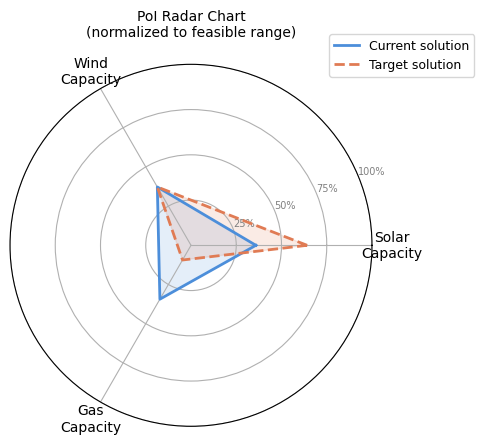

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Mock data (will be updated after real navigation) ────────────
poi_names   = ["Solar\nCapacity", "Wind\nCapacity", "Gas\nCapacity"]
poi_min     = np.array([1.2, 0.8, 0.0])
poi_max     = np.array([6.5, 5.1, 3.2])
current_vals = np.array([3.1, 2.4, 1.1])
target_vals  = np.array([4.6, 2.4, 0.3])

# Normalize to [0, 1]
current_norm = (current_vals - poi_min) / (poi_max - poi_min)
target_norm  = (target_vals  - poi_min) / (poi_max - poi_min)

N      = len(poi_names)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

def to_radar(vals):
    v = vals.tolist()
    v += v[:1]
    return v

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))

ax.plot(angles, to_radar(current_norm), color="#4C8EDA", lw=2, label="Current solution")
ax.fill(angles, to_radar(current_norm), color="#4C8EDA", alpha=0.15)

ax.plot(angles, to_radar(target_norm), color="#E07B54", lw=2, linestyle="--",
        label="Target solution")
ax.fill(angles, to_radar(target_norm), color="#E07B54", alpha=0.15)

ax.set_thetagrids(np.degrees(angles[:-1]), poi_names, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=7, color="grey")
ax.set_title("PoI Radar Chart\n(normalized to feasible range)", fontsize=10, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.tight_layout()
plt.show()


### 4.3 Exploration History

Every time you navigate to a new solution, it is recorded below. Click **Restore** next to any step to go back to that solution and continue exploring from there.

In [11]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

# ── Mock exploration history ─────────────────────────────────────
history = [
    {"step": 1, "label": "Initial solution",   "solar": 3.1, "wind": 2.4, "gas": 1.1, "cost": 1.244},
    {"step": 2, "label": "Increased Solar",    "solar": 4.6, "wind": 2.4, "gas": 0.3, "cost": 1.310},
]

output_history = widgets.Output()

def render_history():
    output_history.clear_output()
    with output_history:
        poi_names = ["Solar", "Wind", "Gas"]
        n = len(history)
        fig, axes = plt.subplots(1, n, figsize=(4 * n, 3), sharey=True)
        if n == 1:
            axes = [axes]

        colors = ["#4C8EDA", "#E07B54", "#4CAF82", "#9B59B6", "#F39C12"]
        for idx, (ax, entry) in enumerate(zip(axes, history)):
            vals = [entry["solar"], entry["wind"], entry["gas"]]
            bars = ax.bar(poi_names, vals, color=colors[idx % len(colors)], alpha=0.8)
            ax.set_title(f"Step {entry['step']}\n{entry['label']}\n"
                         f"Cost: €{entry['cost']:.3f}M", fontsize=9)
            ax.set_ylim(0, 7)
            ax.spines[["top", "right"]].set_visible(False)
            for bar in bars:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                        f"{bar.get_height():.1f}", ha="center", fontsize=8)

        plt.suptitle("Exploration History", fontsize=11, y=1.02)
        plt.tight_layout()
        plt.show()

        print("-" * 50)
        for entry in history:
            print(f"  Step {entry['step']}: {entry['label']:<25} "
                  f"Solar={entry['solar']:.1f}  Wind={entry['wind']:.1f}  "
                  f"Gas={entry['gas']:.1f}  Cost=€{entry['cost']:.3f}M")
        print("-" * 50)
        print("(In the real notebook, clicking Restore will reload that solution.)")

render_history()
display(output_history)


Output()

---
## Section 5 — Traverse

Once navigation has found a target solution, use the **β slider** below to interpolate between the current solution (β = 0) and the target solution (β = 1) along the near-optimal path.

The upper plot shows how each PoI value changes along the path. The lower plot shows the **piecewise-linear cost approximation** — the estimated system cost at each interpolation point, following an approximately cost-optimal route through the near-optimal space.


In [12]:
# ── Mock traverse data ───────────────────────────────────────────
beta_values    = np.linspace(0, 1, 50)

# Piecewise-linear PoI paths (mocked)
solar_path = 3.1 + beta_values * (4.6 - 3.1)
wind_path  = 2.4 + beta_values * (2.4 - 2.4)
gas_path   = 1.1 + beta_values * (0.3 - 1.1)

# Piecewise-linear cost approximation (mocked)
breakpoints = [0.0, 0.3, 0.65, 1.0]
costs       = [1.244, 1.278, 1.310, 1.368]   # in M€/year
cost_interp = np.interp(beta_values, breakpoints, costs)

# ── β slider ─────────────────────────────────────────────────────
beta_slider   = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.01,
                    description="β (path):", continuous_update=True,
                    style={"description_width": "80px"},
                    layout=widgets.Layout(width="500px"))
output_trav   = widgets.Output()

def update_traverse(change):
    beta = beta_slider.value
    output_trav.clear_output(wait=True)
    with output_trav:
        solar_b = 3.1 + beta * (4.6 - 3.1)
        wind_b  = 2.4
        gas_b   = 1.1 + beta * (0.3 - 1.1)
        cost_b  = float(np.interp(beta, breakpoints, costs))

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6),
                                        gridspec_kw={"height_ratios": [2, 1]})

        # ── PoI paths ──────────────────────────────────────────────
        ax1.plot(beta_values, solar_path, color="#4C8EDA", lw=2, label="Solar Capacity")
        ax1.plot(beta_values, wind_path,  color="#4CAF82", lw=2, label="Wind Capacity")
        ax1.plot(beta_values, gas_path,   color="#E07B54", lw=2, label="Gas Capacity")
        ax1.axvline(beta, color="black", lw=1.2, linestyle="--", alpha=0.6)
        ax1.plot(beta, solar_b, "o", color="#4C8EDA", ms=8, zorder=5)
        ax1.plot(beta, wind_b,  "o", color="#4CAF82", ms=8, zorder=5)
        ax1.plot(beta, gas_b,   "o", color="#E07B54", ms=8, zorder=5)
        ax1.set_ylabel("Capacity (GW)", fontsize=10)
        ax1.set_title(f"Traverse Path  (β = {beta:.2f})", fontsize=11, pad=8)
        ax1.legend(fontsize=9, loc="upper right")
        ax1.spines[["top", "right"]].set_visible(False)
        ax1.set_xlim(0, 1)

        # ── Cost approximation ────────────────────────────────────
        ax2.plot(beta_values, cost_interp, color="#9B59B6", lw=2,
                 label="Cost approx. (piecewise-linear)")
        ax2.axvline(beta, color="black", lw=1.2, linestyle="--", alpha=0.6)
        ax2.plot(beta, cost_b, "o", color="#9B59B6", ms=8, zorder=5)
        ax2.set_xlabel("β (interpolation parameter)", fontsize=10)
        ax2.set_ylabel("Cost (M€/yr)", fontsize=10)
        ax2.annotate(f"  €{cost_b:.3f}M", xy=(beta, cost_b),
                     fontsize=9, color="#9B59B6", va="bottom")
        ax2.spines[["top", "right"]].set_visible(False)
        ax2.set_xlim(0, 1)
        ax2.legend(fontsize=9)

        plt.tight_layout()
        plt.show()

beta_slider.observe(update_traverse, names="value")
display(beta_slider)
display(output_trav)
update_traverse(None)


FloatSlider(value=0.0, description='β (path):', layout=Layout(width='500px'), max=1.0, step=0.01, style=Slider…

Output()

---
## Section 6 — Save Results

After exploring, you can save any solution you found for further analysis.


In [13]:
# ── Save selected solution ───────────────────────────────────────
save_btn    = widgets.Button(description="💾  Save current solution",
                button_style="success", layout=widgets.Layout(width="220px"))
output_save = widgets.Output()

def on_save(b):
    with output_save:
        # network_solution.export_to_netcdf("selected_solution.nc")
        print("✓ Solution saved to: selected_solution.nc")

save_btn.on_click(on_save)
display(save_btn)
display(output_save)


Button(button_style='success', description='💾  Save current solution', layout=Layout(width='220px'), style=But…

Output()